# Day 2: The Math Behind a Qubit

**Clemson Quantum Club** · SC Quantathon v3 Bootcamp · [clemsonquantum.com](https://clemsonquantum.com)

In this notebook:
1. Setup
2. Complex numbers: magnitude and phase
3. A qubit is a vector: amplitudes and the Born rule
4. Dirac notation: kets, bras, and inner products
5. Global phase and relative phase
6. The Bloch sphere
7. Gates are matrices: unitarity and reversibility
8. Interference: two paths that cancel
9. Measuring $|+\rangle$ and $|-\rangle$ on real hardware (optional)

> Cells marked **Your turn** have a few lines for you to fill in. Cells marked **Checkpoint** contain `assert` statements: if the cell runs without an error, the answer above it is correct. This is the solutions notebook: every Your turn cell is filled in and hardware runs are switched on.

## 1. Setup

Same two paths as Day 1: the `scqv3` conda environment, or qBraid Lab with the default Python environment. Everything until section 9 runs on a simulator.

In [68]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.primitives import StatevectorSampler

np.set_printoptions(precision=3, suppress=True)

SHOTS = 1000
RUN_ON_HARDWARE = True      # section 9 only; leave False to use a cached result

sampler = StatevectorSampler(seed=np.random.default_rng(7))

def counts_of(qc, shots=SHOTS):
    return sampler.run([qc], shots=shots).result()[0].data.meas.get_counts()

# Load the IBM account saved on Day 1, if there is one. Nothing here needs it until section 9.
try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(name="scqv3")
    print("IBM account 'scqv3' loaded.")
except Exception as e:
    service = None
    print("No saved IBM account:", type(e).__name__, "(fine until section 9)")

IBM account 'scqv3' loaded.


## 2. Complex numbers: magnitude and phase

Every number in a qubit's description is complex. Written in polar form, a complex number is a length and an angle:

$$z = x + iy = r\,e^{i\phi}, \qquad r = |z| = \sqrt{x^2 + y^2}, \qquad e^{i\phi} = \cos\phi + i\sin\phi .$$

Two facts carry the whole day. The magnitude of $e^{i\phi}$ is 1 for every $\phi$, and multiplying two such numbers adds their angles: $e^{i a}\,e^{i b} = e^{i(a+b)}$.

In [69]:
z = 1 + 1j
r, phi = abs(z), np.angle(z)

print("z           =", z)
print("r           =", r)
print("phi         =", phi, "rad  =", np.degrees(phi), "deg")
print("r e^{i phi} =", r * np.exp(1j * phi))

# Checkpoint: polar form rebuilds the number
assert np.isclose(r * np.exp(1j * phi), z)

z           = (1+1j)
r           = 1.4142135623730951
phi         = 0.7853981633974483 rad  = 45.0 deg
r e^{i phi} = (1.0000000000000002+1j)


### Your turn: points on the unit circle

For five random angles, compute `mags`, the magnitudes of $e^{i\phi}$, and `angle_sum`, the angle of the product $e^{i\phi_1} e^{i\phi_2}$ for the first two angles.

In [70]:
rng = np.random.default_rng(seed=3)
phis = rng.uniform(0, 2 * np.pi, size=5)

mags = None
angle_sum = None

### WRITE YOUR CODE BELOW HERE ###
mags = np.abs(np.exp(1j * phis))
angle_sum = np.angle(np.exp(1j * phis[0]) * np.exp(1j * phis[1]))

### YOUR CODE FINISHES HERE ###

In [71]:
# Checkpoint
assert mags is not None and angle_sum is not None, "fill in the cell above"
assert np.allclose(mags, 1), "every e^{i phi} has magnitude 1"
assert np.isclose(np.exp(1j * angle_sum), np.exp(1j * (phis[0] + phis[1]))), "angles add under multiplication"
print("magnitudes:", mags)
print("angle of the product:", angle_sum, " expected:", (phis[0] + phis[1]) % (2 * np.pi))

magnitudes: [1. 1. 1. 1. 1.]
angle of the product: 2.0260738841993575  expected: 2.0260738841993575


## 3. A qubit is a vector

The two classical values become two unit vectors, and a qubit is any unit-length combination of them:

$$|0\rangle = \begin{pmatrix}1\\0\end{pmatrix},\qquad |1\rangle = \begin{pmatrix}0\\1\end{pmatrix},\qquad |\psi\rangle = \alpha|0\rangle + \beta|1\rangle = \begin{pmatrix}\alpha\\\beta\end{pmatrix},\qquad |\alpha|^2 + |\beta|^2 = 1 .$$

$\alpha$ and $\beta$ are the **amplitudes**. The **Born rule** says the probability of reading 0 is $|\alpha|^2$ and of reading 1 is $|\beta|^2$; normalization is the statement that those two add to 1. Amplitudes are complex, so two different states can have the same probabilities.

In [72]:
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

alpha, beta = 1 / np.sqrt(2), 1 / np.sqrt(2)
plus  = alpha * ket0 + beta * ket1        # the fair coin from Day 1
minus = alpha * ket0 - beta * ket1        # also a fair coin, but a different vector

for name, v in [("plus", plus), ("minus", minus)]:
    print(f"{name:<6} = {v}   probabilities = {np.abs(v) ** 2}")

# Checkpoint: both are normalized
assert np.isclose(np.sum(np.abs(plus) ** 2), 1) and np.isclose(np.sum(np.abs(minus) ** 2), 1)

plus   = [0.707+0.j 0.707+0.j]   probabilities = [0.5 0.5]
minus  = [ 0.707+0.j -0.707+0.j]   probabilities = [0.5 0.5]


Qiskit's `Statevector` holds the same two numbers. Sampling it is the same thing as running a circuit that prepares the state and measures it: the probabilities become counts.

Statevector([0.707+0.j, 0.707+0.j],
            dims=(2,))
probabilities: [0.5 0.5]


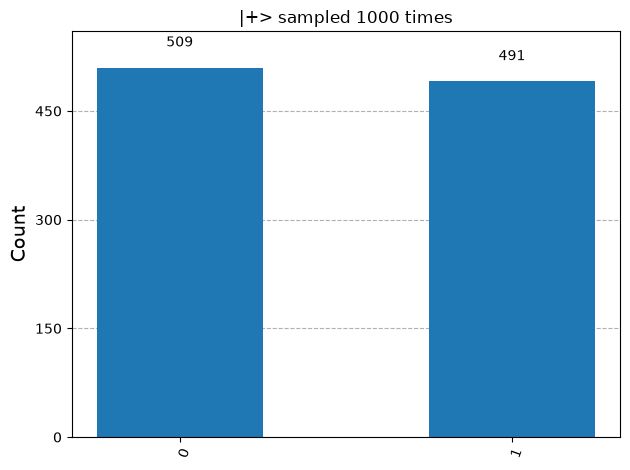

In [73]:
sv_plus = Statevector(plus)
print(sv_plus)
print("probabilities:", sv_plus.probabilities())

plot_histogram(sv_plus.sample_counts(SHOTS), title=f"|+> sampled {SHOTS} times")

### Your turn: a biased qubit

Choose real amplitudes `alpha` and `beta` so that $P(0) = 0.8$ and the state is normalized.

In [74]:
alpha = None
beta = None

### WRITE YOUR CODE BELOW HERE ###
alpha = np.sqrt(0.8)
beta = np.sqrt(0.2)

### YOUR CODE FINISHES HERE ###

biased = [0.894+0.j 0.447+0.j]   probabilities = [0.8 0.2]


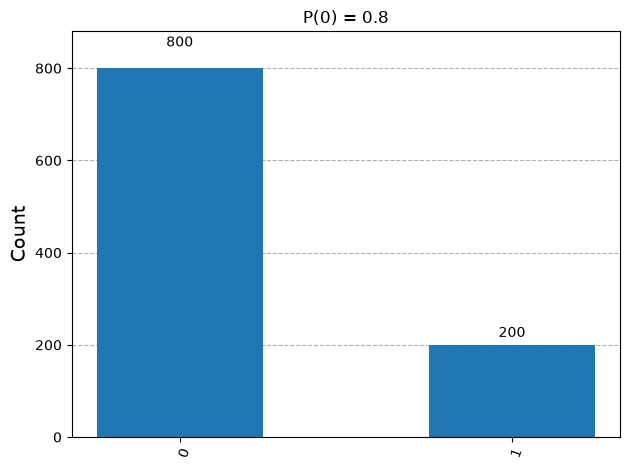

In [75]:
# Checkpoint
assert alpha is not None and beta is not None, "fill in the cell above"
biased = alpha * ket0 + beta * ket1
assert np.isclose(np.abs(alpha) ** 2, 0.8), "P(0) should be 0.8"
assert np.isclose(np.sum(np.abs(biased) ** 2), 1), "the state should be normalized"
print("biased =", biased, "  probabilities =", np.abs(biased) ** 2)
plot_histogram(Statevector(biased).sample_counts(SHOTS), title="P(0) = 0.8")

## 4. Dirac notation

The vector $|\psi\rangle$ is a **ket**, a column. The **bra** $\langle\psi|$ is the same vector flipped into a row with every entry conjugated. Putting a bra and a ket together gives a number, the **inner product**:

$$\langle\phi|\psi\rangle = \sum_i \bar\phi_i\,\psi_i .$$

Three consequences. $\langle\psi|\psi\rangle = \sum_i|\psi_i|^2 = 1$ for a normalized state. $\langle 0|1\rangle = 0$: the two basis states are **orthogonal**, which is what makes them perfectly distinguishable by a measurement. And $|\langle 0|\psi\rangle|^2 = |\alpha|^2$: the Born rule is the squared inner product with the outcome's basis vector.

In [76]:
sv0 = Statevector.from_label("0")
sv1 = Statevector.from_label("1")
sv_plus = Statevector.from_label("+")
sv_minus = Statevector.from_label("-")

print("<0|1>  =", sv0.inner(sv1))
print("<0|+>  =", sv0.inner(sv_plus), "   and |<0|+>|^2 =", abs(sv0.inner(sv_plus)) ** 2, "= P(0) for |+>")
print("<+|->  =", sv_plus.inner(sv_minus))
print("<+|+>  =", sv_plus.inner(sv_plus))

# The same inner product in plain numpy: conjugate the first vector, then dot
print("numpy  <0|+> =", np.vdot(ket0, plus))

# Checkpoint: orthogonal pairs
assert np.isclose(sv0.inner(sv1), 0)
assert np.isclose(sv_plus.inner(sv_minus), 0), "|+> and |-> are orthogonal"
assert np.isclose(abs(sv0.inner(sv_plus)) ** 2, sv_plus.probabilities()[0])

<0|1>  = 0j
<0|+>  = (0.7071067811865475+0j)    and |<0|+>|^2 = 0.4999999999999999 = P(0) for |+>
<+|->  = (-2.2371143170757382e-17+0j)
<+|+>  = (0.9999999999999998+0j)
numpy  <0|+> = (0.7071067811865475+0j)


## 5. Global phase and relative phase

Multiply a whole state by $e^{i\gamma}$ and nothing observable changes: every probability is $|e^{i\gamma}\psi_i|^2 = |\psi_i|^2$, and the same is true after any gate, because gates are linear. Such a **global phase** is invisible, and Qiskit's `equiv` treats two states that differ only by one as the same state.

A phase between the two amplitudes is different. $|+\rangle$ and $|-\rangle$ differ only by the sign of $\beta$, a **relative phase** of $e^{i\pi} = -1$, and section 4 showed they are orthogonal: as different as two states can be.

In [77]:
gamma = 0.9
sv_plus_g = Statevector(np.exp(1j * gamma) * plus)

print("|+> with a global phase:", sv_plus_g)
print("probabilities:          ", sv_plus_g.probabilities())
print("same state?             ", sv_plus.equiv(sv_plus_g))
print()
print("|+> vs |->:  probabilities", sv_plus.probabilities(), sv_minus.probabilities())
print("same state?             ", sv_plus.equiv(sv_minus))

|+> with a global phase: Statevector([0.44+0.554j, 0.44+0.554j],
            dims=(2,))
probabilities:           [0.5 0.5]
same state?              True

|+> vs |->:  probabilities [0.5 0.5] [0.5 0.5]
same state?              False


A measurement in the computational basis cannot tell $|+\rangle$ from $|-\rangle$: both give 50/50. The circuits below prepare each state and measure it.

direct: {'1': 498, '0': 502} {'1': 489, '0': 511}


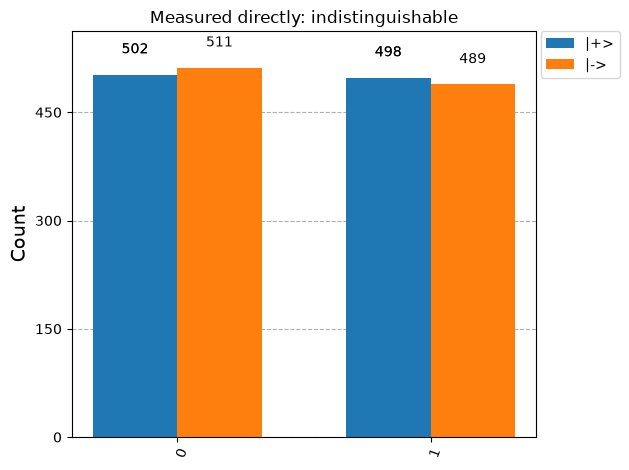

In [78]:
prep_plus = QuantumCircuit(1)
prep_plus.h(0)                    # H|0> = |+>

prep_minus = QuantumCircuit(1)
prep_minus.h(0)
prep_minus.z(0)                   # Z|+> = |->

qc_plus_z, qc_minus_z = prep_plus.copy(), prep_minus.copy()
qc_plus_z.measure_all()
qc_minus_z.measure_all()

counts_plus_z, counts_minus_z = counts_of(qc_plus_z), counts_of(qc_minus_z)
print("direct:", counts_plus_z, counts_minus_z)
plot_histogram([counts_plus_z, counts_minus_z], legend=["|+>", "|->"],
               title="Measured directly: indistinguishable")

### Your turn: a measurement that tells them apart

$H$ maps $|+\rangle$ back to $|0\rangle$ and $|-\rangle$ to $|1\rangle$. Starting from copies of `prep_plus` and `prep_minus`, apply `h(0)` to each, measure, and store the counts in `counts_plus` and `counts_minus`.

In [79]:
qc_plus_x, qc_minus_x = prep_plus.copy(), prep_minus.copy()
counts_plus = counts_minus = None

### WRITE YOUR CODE BELOW HERE ###
qc_plus_x.h(0);  qc_plus_x.measure_all()
qc_minus_x.h(0); qc_minus_x.measure_all()
counts_plus, counts_minus = counts_of(qc_plus_x), counts_of(qc_minus_x)

### YOUR CODE FINISHES HERE ###

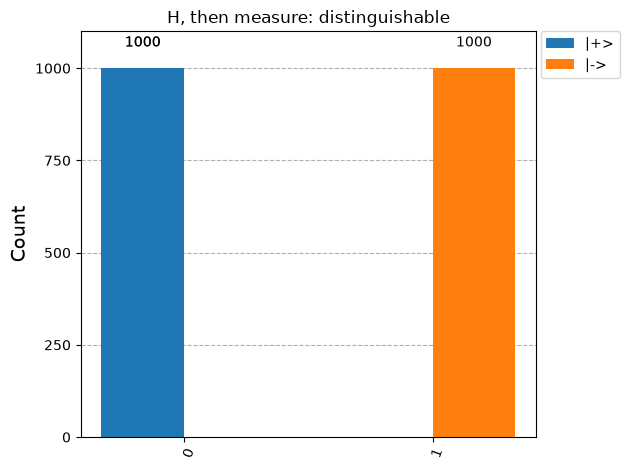

In [80]:
# Checkpoint: the H before the measurement makes the sign visible
assert counts_plus is not None and counts_minus is not None, "fill in the cell above"
assert counts_plus == {"0": SHOTS}, counts_plus
assert counts_minus == {"1": SHOTS}, counts_minus
plot_histogram([counts_plus, counts_minus], legend=["|+>", "|->"], title="H, then measure: distinguishable")

## 6. The Bloch sphere

Two complex amplitudes are four real numbers. Normalization removes one, and the invisible global phase removes another, so a qubit state has two real parameters. Choosing $\alpha$ real and non-negative, they are two angles:

$$|\psi\rangle = \cos\tfrac{\theta}{2}\,|0\rangle + e^{i\phi}\sin\tfrac{\theta}{2}\,|1\rangle, \qquad 0 \le \theta \le \pi,\quad 0 \le \phi < 2\pi .$$

The pair $(\theta, \phi)$ is a point on a sphere. $\theta = 0$ is the north pole $|0\rangle$, $\theta = \pi$ is the south pole $|1\rangle$, and the equator $\theta = \pi/2$ holds every 50/50 state, with $|+\rangle$ at $\phi = 0$ and $|-\rangle$ at $\phi = \pi$. The point's Cartesian coordinates are the three expectation values

$$\big(\langle X\rangle, \langle Y\rangle, \langle Z\rangle\big) = (\sin\theta\cos\phi,\; \sin\theta\sin\phi,\; \cos\theta),$$

which is why the sphere is more than a picture: every coordinate is something a measurement can estimate.

Statevector([0.866+0.j   , 0.354+0.354j],
            dims=(2,))
P(0) = cos^2(theta/2) = 0.7500000000000001   from the state: 0.7500000000000001


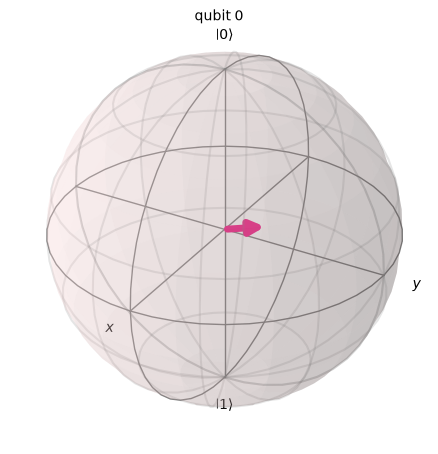

In [81]:
def bloch_state(theta, phi):
    return Statevector([np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2)])

theta, phi = np.pi / 3, np.pi / 4
psi = bloch_state(theta, phi)
print(psi)
print("P(0) = cos^2(theta/2) =", np.cos(theta / 2) ** 2, "  from the state:", psi.probabilities()[0])

plot_bloch_multivector(psi)

### Your turn: coordinates from expectation values

Complete `bloch_vector(state)` so that it returns the numpy array $(\langle X\rangle, \langle Y\rangle, \langle Z\rangle)$. `state.expectation_value(Pauli("X"))` gives $\langle X\rangle$; take the real part.

In [82]:
def bloch_vector(state):
    x = y = z = None

    ### WRITE YOUR CODE BELOW HERE ###
    x = state.expectation_value(Pauli("X")).real
    y = state.expectation_value(Pauli("Y")).real
    z = state.expectation_value(Pauli("Z")).real

    ### YOUR CODE FINISHES HERE ###
    return np.array([x, y, z])

In [83]:
# Checkpoint: poles, equator, and the (theta, phi) formula
assert bloch_vector(sv0)[0] is not None, "bloch_vector is not finished: fill in the cell above"
assert np.allclose(bloch_vector(sv0), [0, 0, 1])
assert np.allclose(bloch_vector(sv1), [0, 0, -1])
assert np.allclose(bloch_vector(sv_plus), [1, 0, 0])
assert np.allclose(bloch_vector(sv_minus), [-1, 0, 0])
expected = [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
assert np.allclose(bloch_vector(psi), expected), (bloch_vector(psi), expected)
print("bloch_vector(psi) =", bloch_vector(psi), "  expected", np.round(expected, 3))

bloch_vector(psi) = [0.612 0.612 0.5  ]   expected [0.612 0.612 0.5  ]


## 7. Gates are matrices

A gate on one qubit is a $2\times 2$ matrix $U$ acting by multiplication, $|\psi\rangle \mapsto U|\psi\rangle$. For the result to stay normalized for every input, $U$ must be **unitary**: $U^\dagger U = I$, where $U^\dagger$ is the conjugate transpose. A unitary always has an inverse, namely $U^\dagger$, so every quantum gate can be undone. The three gates of the week:

$$X = \begin{pmatrix}0&1\\1&0\end{pmatrix},\qquad Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix},\qquad H = \frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}.$$

$X$ swaps the amplitudes (the quantum NOT). $Z$ flips the sign of $\beta$ (a relative phase, invisible to a direct measurement). $H$ turns $|0\rangle$ into $|+\rangle$.

In [84]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

print("X|0> =", X @ ket0)
print("Z|1> =", Z @ ket1)
print("H|0> =", H @ ket0)
print("Z|+> =", Z @ plus, " = |->")

# Checkpoint: unitarity, U^dagger U = I, and therefore reversibility
for name, U in [("X", X), ("Z", Z), ("H", H)]:
    assert np.allclose(U.conj().T @ U, np.eye(2), atol=1e-12), f"{name} is not unitary"
    assert np.allclose(U.conj().T @ (U @ plus), plus), f"{name} cannot be undone by its adjoint"
print("X, Z, H are unitary and each is undone by its adjoint")

X|0> = [0.+0.j 1.+0.j]
Z|1> = [ 0.+0.j -1.+0.j]
H|0> = [0.707+0.j 0.707+0.j]
Z|+> = [ 0.707+0.j -0.707+0.j]  = |->
X, Z, H are unitary and each is undone by its adjoint


In Qiskit, `Operator` wraps a matrix and `Statevector.evolve` applies it. A circuit is itself a matrix: `Operator(qc)` multiplies its gates together.

In [85]:
print("H|0> equals |+>:", sv0.evolve(Operator(H)).equiv(sv_plus))

qc_h = QuantumCircuit(1)
qc_h.h(0)
print("Operator of a one-gate circuit:\n", Operator(qc_h).data)
print("matches our H:", np.allclose(Operator(qc_h).data, H))

H|0> equals |+>: True
Operator of a one-gate circuit:
 [[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
matches our H: True


### Your turn: the $Y$ gate

The third Pauli gate is $Y = \begin{pmatrix}0&-i\\i&0\end{pmatrix}$. Write it as a numpy array `Y`.

In [86]:
Y = None

### WRITE YOUR CODE BELOW HERE ###
Y = np.array([[0, -1j], [1j, 0]])

### YOUR CODE FINISHES HERE ###

In [87]:
# Checkpoint: unitary, Y = iXZ, and Y|0> = i|1>
assert Y is not None, "fill in the cell above"
assert np.allclose(Y.conj().T @ Y, np.eye(2), atol=1e-12), "Y should be unitary"
assert np.allclose(Y, 1j * X @ Z), "Y should equal i X Z"
assert np.allclose(Y @ ket0, 1j * ket1), "Y|0> should be i|1>"
print("Y|0> =", Y @ ket0, "   Y|1> =", Y @ ket1)

Y|0> = [0.+0.j 0.+1.j]    Y|1> = [0.-1.j 0.+0.j]


## 8. Interference: two paths that cancel

Apply $H$ twice. The amplitude to end in $|1\rangle$ is a sum over the two intermediate states,

$$\langle 1|HH|0\rangle = \sum_{k\in\{0,1\}} H_{1k}H_{k0} = \underbrace{\tfrac{1}{\sqrt2}\cdot\tfrac{1}{\sqrt2}}_{\text{via }|0\rangle} + \underbrace{\big(-\tfrac{1}{\sqrt2}\big)\cdot\tfrac{1}{\sqrt2}}_{\text{via }|1\rangle} = 0 .$$

Each path alone would give probability $1/4$. Together they give zero, because the second path carries a minus sign. Probabilities never cancel; amplitudes do.

In [88]:
via_0 = H[1, 0] * H[0, 0]
via_1 = H[1, 1] * H[1, 0]
print("path via |0>:", via_0, "  path via |1>:", via_1, "  sum:", via_0 + via_1)
print("H H =\n", H @ H)

qc_hh = QuantumCircuit(1)
qc_hh.h(0)
qc_hh.h(0)
print("state after H H:", Statevector(qc_hh))

qc_hh.measure_all()
counts_hh = counts_of(qc_hh)

# Checkpoint: the qubit is back in |0> every time
assert counts_hh == {"0": SHOTS}, counts_hh
print(counts_hh)

path via |0>: (0.4999999999999999+0j)   path via |1>: (-0.4999999999999999+0j)   sum: 0j
H H =
 [[ 1.+0.j -0.+0.j]
 [-0.+0.j  1.+0.j]]
state after H H: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
{'0': 1000}


### Your turn: a $Z$ between the two Hadamards

Build the circuit $H$, then $Z$, then $H$, measure it, and store the counts in `counts_hzh`. Predict the histogram before running: the $Z$ flips the sign of the $|1\rangle$ path, so the two paths that cancelled now add.

In [89]:
counts_hzh = None

### WRITE YOUR CODE BELOW HERE ###
qc_hzh = QuantumCircuit(1)
qc_hzh.h(0); qc_hzh.z(0); qc_hzh.h(0)
qc_hzh.measure_all()
counts_hzh = counts_of(qc_hzh)

### YOUR CODE FINISHES HERE ###

In [90]:
# Checkpoint: HZH = X, so the qubit ends in |1> every time
assert counts_hzh is not None, "fill in the cell above"
assert counts_hzh == {"1": SHOTS}, counts_hzh
assert np.allclose(H @ Z @ H, X)
print(counts_hzh, "   and H Z H =\n", H @ Z @ H)

{'1': 1000}    and H Z H =
 [[-0.+0.j  1.+0.j]
 [ 1.+0.j -0.+0.j]]


## 9. Measuring $|+\rangle$ and $|-\rangle$ on real hardware (optional)

Section 5's two experiments on a real device: $|+\rangle$ and $|-\rangle$ measured directly, then measured after an $H$. Four circuits in one job, about 4 seconds of QPU time. Runs only if `RUN_ON_HARDWARE = True` and the account loaded in section 1; otherwise the cell after uses counts cached from a recorded run; the processor and the counts are listed in that cell.

In [91]:
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

labels = ["|+> direct", "|-> direct", "|+> after H", "|-> after H"]
circuits = []
for prep in (prep_plus, prep_minus):
    qc = prep.copy(); qc.measure_all(); circuits.append(qc)          # measured directly
for prep in (prep_plus, prep_minus):
    qc = prep.copy(); qc.h(0); qc.measure_all(); circuits.append(qc)  # H, then measured

job = None
if RUN_ON_HARDWARE and service is not None:
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=1)
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    job = Sampler(mode=backend).run(pm.run(circuits), shots=SHOTS)
    print(f"Submitted to {backend.name}, job id {job.job_id()}")
else:
    print("RUN_ON_HARDWARE is False or no account: using the cached counts below.")

Submitted to ibm_kingston, job id dal14kot9ckc739kv7n0


In [95]:
# Cached counts: recorded on ibm_kingston (a Heron r2 processor, physical qubit 0), 1000 shots each, in the order of `labels`.
CACHED_QPU_COUNTS = [
    {"0": 308, "1": 692},
    {"0": 299, "1": 701},
    {"0": 453, "1": 547},
    {"0": 148, "1": 852},
]

def qpu_counts_or_cached(job):
    if job is None:
        return CACHED_QPU_COUNTS
    try:
        if job.status() == "DONE":
            return [r.data.meas.get_counts() for r in job.result()]
        print(f"Job is {job.status()}; using cached counts for now.")
    except Exception as e:
        print("Could not fetch the job:", e)
    return CACHED_QPU_COUNTS

qpu_counts = qpu_counts_or_cached(job)
sim_counts = [counts_of(qc) for qc in circuits]
exact_counts = [{str(k): int(round(p * SHOTS)) for k, p in Statevector(qc.remove_final_measurements(inplace=False)).probabilities_dict().items()}
                for qc in circuits]                       # the Born rule of section 3, as counts

for label, e, s, q in zip(labels, exact_counts, sim_counts, qpu_counts):
    print(f"{label:<14} exact {e}   simulator {s}   hardware {q}")

|+> direct     exact {'0': 500, '1': 500}   simulator {'1': 513, '0': 487}   hardware {'1': 692, '0': 308}
|-> direct     exact {'0': 500, '1': 500}   simulator {'1': 495, '0': 505}   hardware {'0': 299, '1': 701}
|+> after H    exact {'0': 1000}   simulator {'0': 1000}   hardware {'1': 547, '0': 453}
|-> after H    exact {'1': 1000}   simulator {'1': 1000}   hardware {'0': 148, '1': 852}


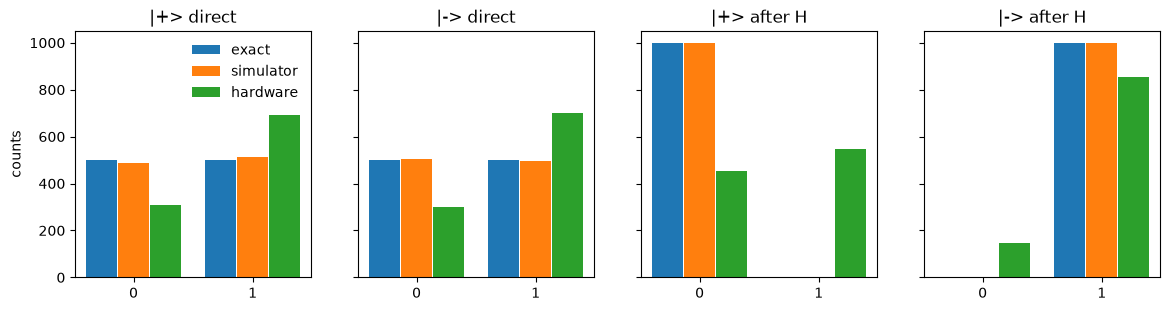

In [96]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for ax, label, e, s, q in zip(axes, labels, exact_counts, sim_counts, qpu_counts):
    ax.bar([-0.27, 0.73], [e.get("0", 0), e.get("1", 0)], 0.26, label="exact")
    ax.bar([0.0, 1.0], [s.get("0", 0), s.get("1", 0)], 0.26, label="simulator")
    ax.bar([0.27, 1.27], [q.get("0", 0), q.get("1", 0)], 0.26, label="hardware")
    ax.set_xticks([0, 1], ["0", "1"]); ax.set_title(label)
axes[0].set_ylabel("counts"); axes[0].legend(frameon=False)
plt.show()

The exact column is the Born rule; the simulator draws from it, so the direct measurements come out near 50/50 and the measurements after $H$ certain. On the processor, read the two after-$H$ circuits first. The transpiler reduces them to a bare measurement of $|0\rangle$ and to $X$ followed by a measurement, so they are a readout test in disguise: the fraction of 1s in the third circuit is the rate at which a prepared $|0\rangle$ is misread, and the fraction of 0s in the fourth is the rate for a prepared $|1\rangle$. Feed those two rates into a 50/50 state and you get what the direct measurements should read on that qubit. If the direct pair sits near 50/50 and the after-$H$ pair near certainty, the readout was good; if not, as in the recorded run, the readout rather than the state is what moved. Day 5 measures readout error on purpose and shows how to correct for it; the notes work through the recorded run.

## 10. Summary

- A complex number is a magnitude and an angle, $z = re^{i\phi}$; $|e^{i\phi}| = 1$ and angles add under multiplication.
- A qubit is a normalized vector $\alpha|0\rangle + \beta|1\rangle$. The Born rule gives $P(0) = |\alpha|^2$, $P(1) = |\beta|^2$.
- Bras are conjugated rows, kets are columns, and $\langle\phi|\psi\rangle$ is their inner product. Orthogonal states are perfectly distinguishable; $|\langle x|\psi\rangle|^2$ is the probability of outcome $x$.
- A global phase $e^{i\gamma}$ is invisible. A relative phase between $\alpha$ and $\beta$ is a different state, visible after a change of basis.
- Every qubit state is a point $(\theta,\phi)$ on the Bloch sphere, with Cartesian coordinates $(\langle X\rangle,\langle Y\rangle,\langle Z\rangle)$.
- Gates are unitary matrices, $U^\dagger U = I$, so every gate is reversible. $X$ swaps amplitudes, $Z$ flips a sign, $H$ makes superpositions.
- Amplitudes add along paths and can cancel. $HH|0\rangle = |0\rangle$ because the two routes to $|1\rangle$ have opposite signs; a $Z$ in between turns the cancellation into reinforcement, $HZH = X$.

## Further reading

- [Basics of Quantum Information, lesson 1: Single systems](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/introduction), John Watrous
- [Statevector](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector) and [Operator](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Operator) in the Qiskit API reference
- M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, sections 1.2 and 1.3
- [Bloch sphere](https://en.wikipedia.org/wiki/Bloch_sphere) on Wikipedia, for the geometry